### 1)Not Using the Early Stopping 


In [ ]:
import tensorflow as tf
import numpy as np 
import pandas as pd 
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns


In [5]:
X,y =make_circles(n_samples=100,noise=0.1,random_state=1)


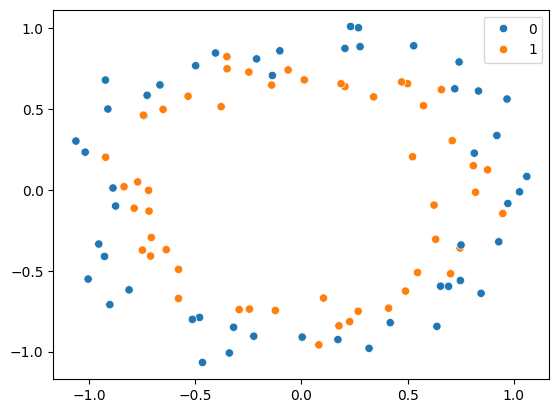

In [8]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [10]:
model = Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

c:\Users\Yaali Madad\Desktop\programs\Deeplearning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs=3000,validation_data=(X_test,y_test))


Epoch 1/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.4625 - loss: 0.6957 - val_accuracy: 0.5500 - val_loss: 0.6903
Epoch 2/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5125 - loss: 0.6932 - val_accuracy: 0.5500 - val_loss: 0.6937
Epoch 3/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5125 - loss: 0.6924 - val_accuracy: 0.4500 - val_loss: 0.6974
Epoch 4/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5375 - loss: 0.6903 - val_accuracy: 0.3500 - val_loss: 0.6986
Epoch 5/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5250 - loss: 0.6897 - val_accuracy: 0.3500 - val_loss: 0.7007
Epoch 6/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.6882 - val_accuracy: 0.3500 - val_loss: 0.7032
Epoch 7/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5250 - loss: 0.6873 - val_accuracy: 0.4500 - val_loss: 0.7053
Epoch 8/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5500 - loss: 0.6865 - val_accuracy: 0.4000 - 

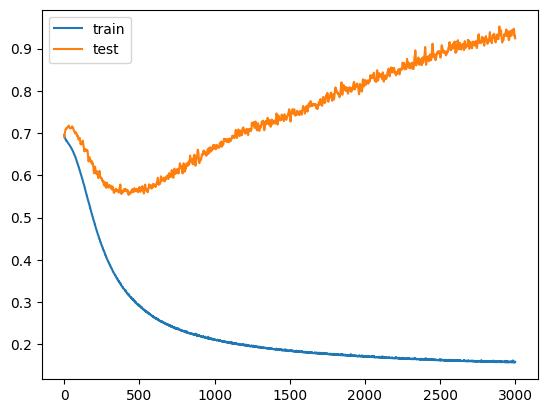

In [12]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 777us/step


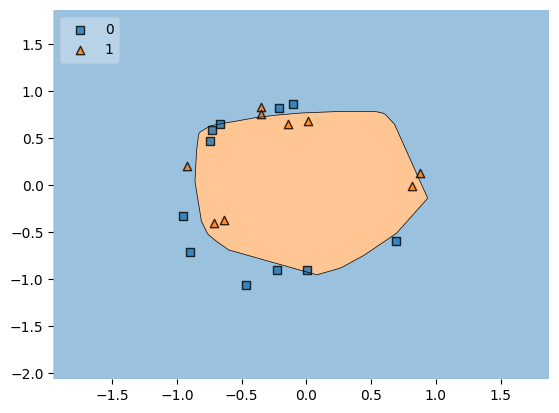

In [14]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
plt.show()

### Using Early Stopping 


In [15]:
model_early=Sequential()
model_early.add(Dense(256,input_dim=2,activation='relu'))
model_early.add(Dense(1,activation='sigmoid'))
model_early.summary()

model_early.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

callbacks = [EarlyStopping(monitor='val_loss',min_delta=0.0001,verbose=1,mode="auto",restore_best_weights=True,patience=100)]
history_early=model_early.fit(X_train,y_train,epochs=3000,validation_data=(X_test,y_test),callbacks=callbacks)




c:\Users\Yaali Madad\Desktop\programs\Deeplearning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5125 - loss: 0.6926 - val_accuracy: 0.4500 - val_loss: 0.6987
Epoch 2/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5125 - loss: 0.6907 - val_accuracy: 0.4000 - val_loss: 0.7022
Epoch 3/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5500 - loss: 0.6890 - val_accuracy: 0.3500 - val_loss: 0.7034
Epoch 4/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5500 - loss: 0.6877 - val_accuracy: 0.3500 - val_loss: 0.7042
Epoch 5/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5625 - loss: 0.6869 - val_accuracy: 0.3500 - val_loss: 0.7053
Epoch 6/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5500 - loss: 0.6856 - val_accuracy: 0.3500 - val_loss: 0.7060
Epoch 7/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5750 - loss: 0.6849 - val_accuracy: 0.4000 - val_loss: 0.7066
Epoch 8/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5750 - loss: 0.6841 - val_accuracy: 0.4000 - 

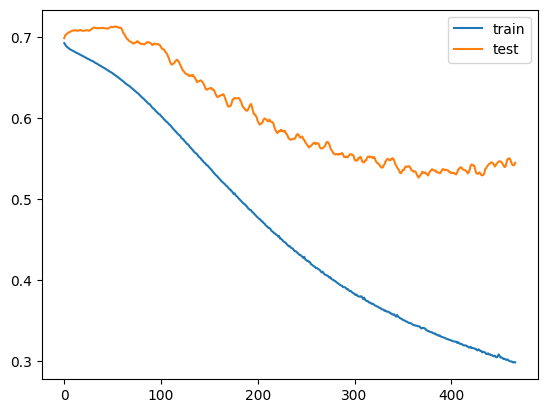

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 822us/step


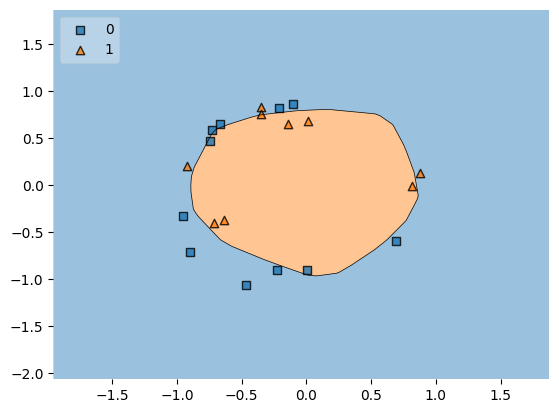

In [17]:
plt.plot(history_early.history['loss'], label='train')
plt.plot(history_early.history['val_loss'], label='test')
plt.legend()
plt.show()

plot_decision_regions(X_test,y_test.ravel(),clf=model_early,legend=2)
plt.show()


